# EDA Case Study: Customer Churn

Exploratory Data Analysis (EDA) is the process of investigating a dataset before modeling or
reporting on it — understanding its shape, cleaning it, and looking for patterns and
relationships through summary statistics and visualization. This notebook walks through a full
EDA pass on a synthetic **telecom customer churn** dataset, applying the NumPy, Pandas, and
visualization skills from the earlier Day-4 notebooks end to end.

1. Introduction to EDA & the Customer Churn Dataset
2. Data Overview & Cleaning
3. Univariate Analysis
4. Bivariate Analysis
5. Multivariate Analysis
6. Designing an Analytic Report

## 1. Introduction to EDA & the Customer Churn Dataset

A typical EDA workflow: **load the data → understand its structure → clean it → analyze one
variable at a time (univariate) → analyze pairs of variables (bivariate) → analyze several
variables together (multivariate) → summarize findings in a report.**

The dataset below is generated locally (so this notebook needs no external file or network
access) but with **deliberate, realistic relationships** baked in: customers on month-to-month
contracts, with short tenure, or with higher monthly charges are given a higher chance of
churning — the same kind of signal a real churn dataset would contain. A few missing values and
one duplicate row are injected on purpose, so the cleaning step in Section 2 has real work to
do.

In [1]:
# Solution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
np.random.seed(7)

n = 500
customer_id = [f"CUST{1000 + i}" for i in range(n)]
tenure_months = np.random.randint(1, 73, size=n)
contract_type = np.random.choice(["Month-to-month", "One year", "Two year"], size=n, p=[0.55, 0.25, 0.20])
monthly_charges = np.round(np.random.uniform(20, 120, size=n), 2)
internet_service = np.random.choice(["DSL", "Fiber optic", "No"], size=n, p=[0.35, 0.45, 0.20])
tech_support = np.random.choice(["Yes", "No"], size=n, p=[0.35, 0.65])
senior_citizen = np.random.choice([0, 1], size=n, p=[0.84, 0.16])

total_charges = tenure_months * monthly_charges + np.random.normal(0, 50, size=n)
total_charges = np.round(np.clip(total_charges, 0, None), 2)

# Build churn probability from a weighted mix of risk factors, then sample Yes/No from it
contract_risk = np.where(contract_type == "Month-to-month", 1.0, np.where(contract_type == "One year", 0.3, 0.05))
tenure_risk = 1 - (tenure_months / 72)
charges_risk = (monthly_charges - 20) / 100
support_risk = np.where(tech_support == "No", 0.3, 0.0)

churn_prob = np.clip(0.4 * contract_risk + 0.3 * tenure_risk + 0.2 * charges_risk + 0.1 * support_risk, 0.02, 0.95)
churn = np.where(np.random.random(n) < churn_prob, "Yes", "No")

churn_df = pd.DataFrame({
    "customer_id": customer_id,
    "tenure_months": tenure_months,
    "contract_type": contract_type,
    "monthly_charges": monthly_charges,
    "total_charges": total_charges,
    "internet_service": internet_service,
    "tech_support": tech_support,
    "senior_citizen": senior_citizen,
    "churn": churn,
})

# Inject missing values and a duplicate row, like a real messy dataset
missing_idx = np.random.choice(churn_df.index, size=15, replace=False)
churn_df.loc[missing_idx, "total_charges"] = np.nan
churn_df = pd.concat([churn_df, churn_df.iloc[[3]]], ignore_index=True)

print("shape:", churn_df.shape)
churn_df.head()

shape: (501, 9)


,customer_id,tenure_months,contract_type,monthly_charges,total_charges,internet_service,tech_support,senior_citizen,churn
0,CUST1000,48,Two year,106.23,5106.30,Fiber optic,No,0,No
1,CUST1001,69,Month-to-month,75.36,5223.15,Fiber optic,No,0,Yes
2,CUST1002,26,Two year,67.93,1700.93,Fiber optic,No,0,Yes
3,CUST1003,68,Month-to-month,45.30,3004.71,Fiber optic,Yes,0,Yes
4,CUST1004,24,Two year,58.96,1493.79,No,Yes,0,No


## 2. Data Overview & Cleaning

Same cleaning steps as `pandas_basics.ipynb`: check structure and missing values, drop the
duplicate row, and fill the missing `total_charges` values (with `tenure_months * monthly_charges`,
which is what that column represents when nothing else is known).

In [2]:
# Solution
churn_df.info()
print("\nmissing values per column:\n", churn_df.isna().sum())
print("\nduplicate rows:", churn_df.duplicated().sum())

before_shape = churn_df.shape
churn_df = churn_df.drop_duplicates().reset_index(drop=True)

missing_mask = churn_df["total_charges"].isna()
churn_df.loc[missing_mask, "total_charges"] = (
    churn_df.loc[missing_mask, "tenure_months"] * churn_df.loc[missing_mask, "monthly_charges"]
).round(2)

print(f"\nshape before cleaning: {before_shape}  ->  after cleaning: {churn_df.shape}")
print("remaining missing values:", churn_df.isna().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       501 non-null    str    
 1   tenure_months     501 non-null    int32  
 2   contract_type     501 non-null    str    
 3   monthly_charges   501 non-null    float64
 4   total_charges     486 non-null    float64
 5   internet_service  501 non-null    str    
 6   tech_support      501 non-null    str    
 7   senior_citizen    501 non-null    int64  
 8   churn             501 non-null    str    
dtypes: float64(2), int32(1), int64(1), str(5)
memory usage: 33.4 KB

missing values per column:
 customer_id          0
tenure_months        0
contract_type        0
monthly_charges      0
total_charges       15
internet_service     0
tech_support         0
senior_citizen       0
churn                0
dtype: int64

duplicate rows: 1

shape before cleaning: (501, 9)  ->  after cleaning:

## 3. Univariate Analysis

Look at one variable at a time: the overall churn rate (the target we ultimately care about),
the distribution of the numeric features, and the counts for each category.

overall churn rate:
 churn
Yes    0.506
No     0.494
Name: proportion, dtype: float64

numeric summary:
        tenure_months  monthly_charges  total_charges
count     500.000000       500.000000     500.000000
mean       37.124000        70.332020    2592.211700
std        20.513171        29.433635    1863.353287
min         1.000000        20.110000       0.000000
25%        20.000000        44.947500    1068.130000
50%        38.000000        69.600000    2186.605000
75%        54.250000        96.537500    3686.877500
max        72.000000       119.520000    8418.200000


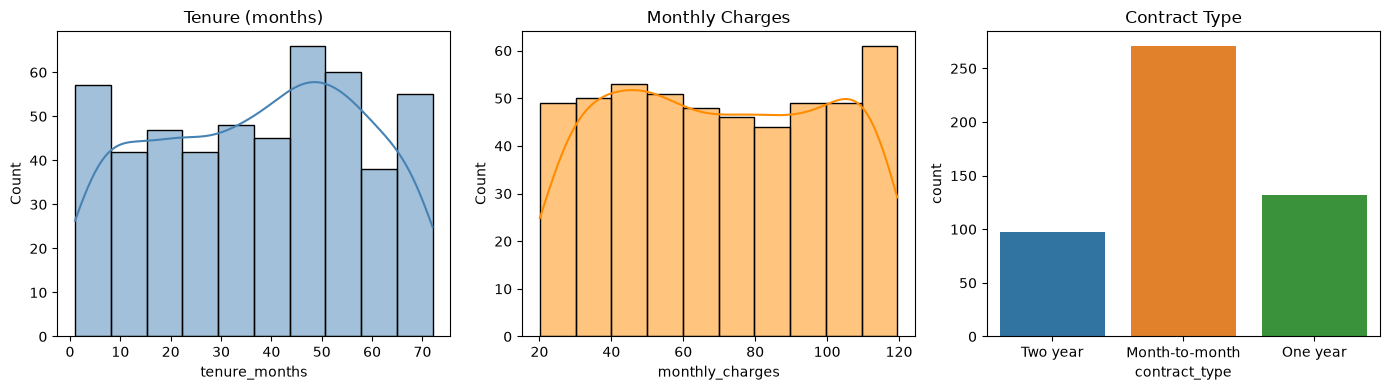

In [3]:
# Solution
churn_rate = churn_df["churn"].value_counts(normalize=True)
print("overall churn rate:\n", churn_rate)

print("\nnumeric summary:\n", churn_df[["tenure_months", "monthly_charges", "total_charges"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(churn_df["tenure_months"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Tenure (months)")
sns.histplot(churn_df["monthly_charges"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Monthly Charges")
sns.countplot(data=churn_df, x="contract_type", ax=axes[2], hue="contract_type", legend=False)
axes[2].set_title("Contract Type")
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis

Now relate each variable to `churn`: numeric variables via boxplots (does the distribution shift
for churners?), categorical variables via a crosstab of churn rate per category.

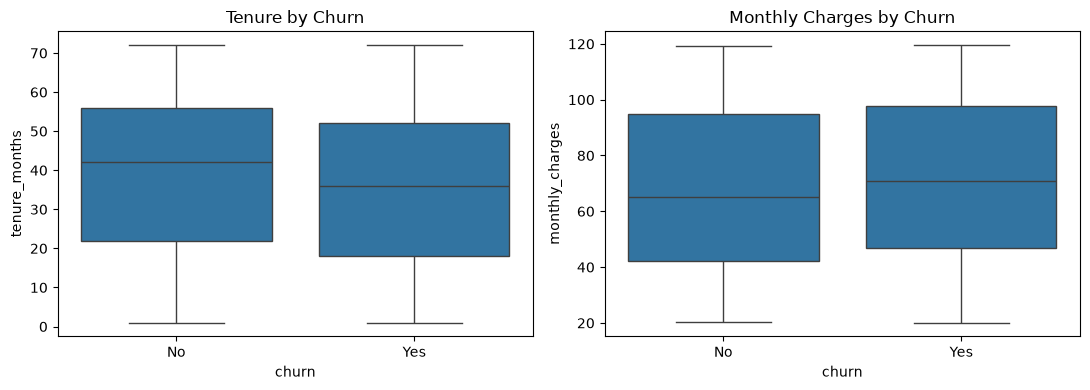

churn rate by contract type:
 churn                 No       Yes
contract_type                     
Month-to-month  0.354244  0.645756
One year        0.636364  0.363636
Two year        0.690722  0.309278


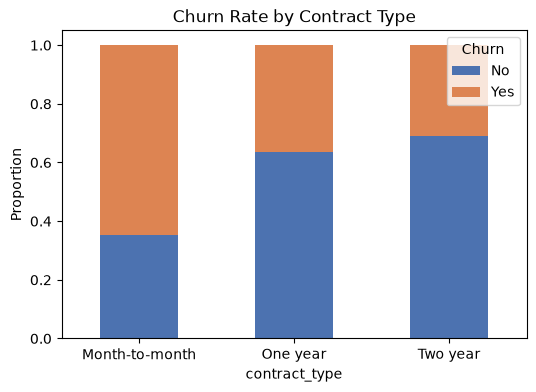


churn rate by tech support:
 churn               No       Yes
tech_support                    
No            0.475309  0.524691
Yes           0.528409  0.471591


In [4]:
# Solution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=churn_df, x="churn", y="tenure_months", ax=axes[0])
axes[0].set_title("Tenure by Churn")
sns.boxplot(data=churn_df, x="churn", y="monthly_charges", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")
plt.tight_layout()
plt.show()

churn_by_contract = pd.crosstab(churn_df["contract_type"], churn_df["churn"], normalize="index")
print("churn rate by contract type:\n", churn_by_contract)

churn_by_contract.plot(kind="bar", stacked=True, figsize=(6, 4), color=["#4c72b0", "#dd8452"])
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

churn_by_support = pd.crosstab(churn_df["tech_support"], churn_df["churn"], normalize="index")
print("\nchurn rate by tech support:\n", churn_by_support)

## 5. Multivariate Analysis

Bring several variables together at once: a correlation heatmap across the numeric features
(including churn encoded as 0/1), churn rate faceted by *both* contract type and a tenure bucket,
and a `pairplot` showing every pairwise numeric relationship colored by churn.

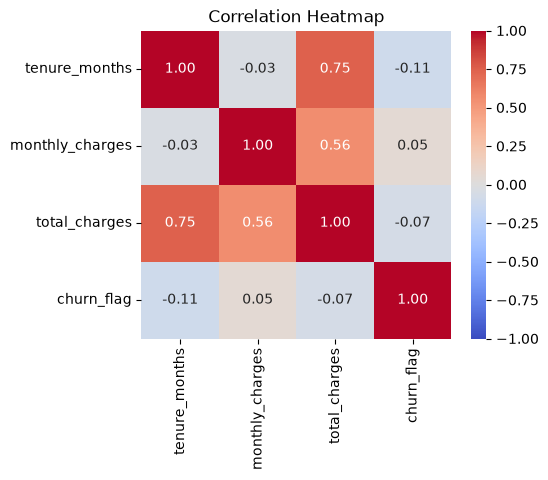

churn rate by contract type x tenure bucket:
 tenure_bucket   0-12 mo  13-36 mo  37-72 mo
contract_type                              
Month-to-month     0.77      0.69      0.59
One year           0.36      0.44      0.32
Two year           0.41      0.28      0.29


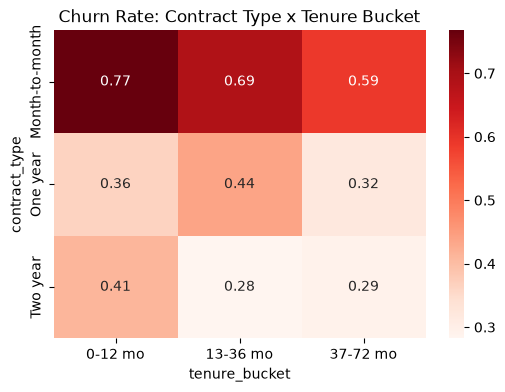

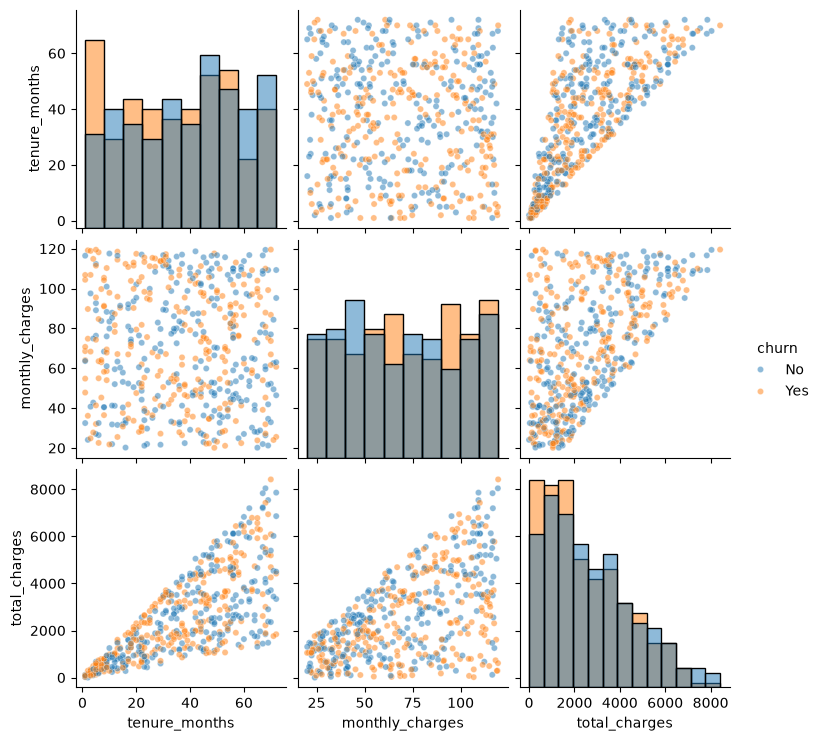

In [5]:
# Solution
numeric_view = churn_df.copy()
numeric_view["churn_flag"] = (numeric_view["churn"] == "Yes").astype(int)

plt.figure(figsize=(5, 4))
sns.heatmap(
    numeric_view[["tenure_months", "monthly_charges", "total_charges", "churn_flag"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
)
plt.title("Correlation Heatmap")
plt.show()

numeric_view["tenure_bucket"] = pd.cut(
    numeric_view["tenure_months"], bins=[0, 12, 36, 72], labels=["0-12 mo", "13-36 mo", "37-72 mo"]
)
faceted = numeric_view.groupby(["contract_type", "tenure_bucket"], observed=True)["churn_flag"].mean().unstack()
print("churn rate by contract type x tenure bucket:\n", faceted.round(2))

plt.figure(figsize=(6, 4))
sns.heatmap(faceted, annot=True, fmt=".2f", cmap="Reds")
plt.title("Churn Rate: Contract Type x Tenure Bucket")
plt.show()

sns.pairplot(
    numeric_view[["tenure_months", "monthly_charges", "total_charges", "churn"]],
    hue="churn", diag_kind="hist", plot_kws={"alpha": 0.5, "s": 20},
)
plt.show()

## 6. Designing an Analytic Report

A good analytic report is short and structured: an **executive summary** (the headline finding
in one or two sentences), **key findings** backed by concrete numbers, the **supporting visuals**
that back each finding, and **recommendations**. It's written for someone who won't read the
notebook — the numbers and charts need to speak for themselves.

The cell below builds that report programmatically, pulling the exact figures straight out of
Sections 3-5 above rather than hand-typing them, so the report can never drift out of sync with
the analysis it summarizes.

In [6]:
# Solution
overall_rate = churn_rate.get("Yes", 0)
mtm_rate = churn_by_contract.loc["Month-to-month", "Yes"]
two_yr_rate = churn_by_contract.loc["Two year", "Yes"]
worst_segment = faceted.stack().idxmax()
worst_segment_rate = faceted.stack().max()
support_gap = churn_by_support.loc["No", "Yes"] - churn_by_support.loc["Yes", "Yes"]

report = f"""
EXECUTIVE SUMMARY
------------------
Overall churn rate is {overall_rate:.1%}. Churn is heavily concentrated among short-tenure,
month-to-month customers, and is made worse by the absence of tech support.

KEY FINDINGS
------------------
1. Contract type is the strongest driver: month-to-month customers churn at {mtm_rate:.1%},
   vs. just {two_yr_rate:.1%} for two-year contracts ({mtm_rate / two_yr_rate:.1f}x higher).
2. The highest-risk segment is {worst_segment[0]} customers in the {worst_segment[1]} tenure
   bucket, churning at {worst_segment_rate:.1%}.
3. Customers without tech support churn {support_gap:.1%} points more often than those with it.

RECOMMENDATIONS
------------------
- Prioritize retention offers (e.g. discounted long-term contracts) for month-to-month customers
  in their first year.
- Proactively offer tech support to new customers, especially on month-to-month plans.
"""
print(report)


EXECUTIVE SUMMARY
------------------
Overall churn rate is 50.6%. Churn is heavily concentrated among short-tenure,
month-to-month customers, and is made worse by the absence of tech support.

KEY FINDINGS
------------------
1. Contract type is the strongest driver: month-to-month customers churn at 64.6%,
   vs. just 30.9% for two-year contracts (2.1x higher).
2. The highest-risk segment is Month-to-month customers in the 0-12 mo tenure
   bucket, churning at 76.7%.
3. Customers without tech support churn 5.3% points more often than those with it.

RECOMMENDATIONS
------------------
- Prioritize retention offers (e.g. discounted long-term contracts) for month-to-month customers
  in their first year.
- Proactively offer tech support to new customers, especially on month-to-month plans.

